# Spatial Density Heatmaps Generation

This module maps the 2D spatial distribution of the tracks across the CR-39 scanned area. It includes a colorbar legend to quantitatively interpret the spatial density.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [ ]:
# Load coordinates data
data_path = 'outputs/candidates_labeled.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f'Successfully loaded {len(df)} tracks.')
else:
    print('Using dummy spatial data.')
    np.random.seed(42)
    # Simulating a hot-spot in the center
    df = pd.DataFrame({
        'cx': np.random.normal(1000, 300, 2000),
        'cy': np.random.normal(1000, 300, 2000)
    })


Successfully loaded 15842 tracks.


Available columns: ['image', 'cy', 'cx', 'area', 'ecc', 'major', 'minor', 'circ', 'mean_int', 'max_int', 'is_watershed_split', 'cluster', 'is_track']


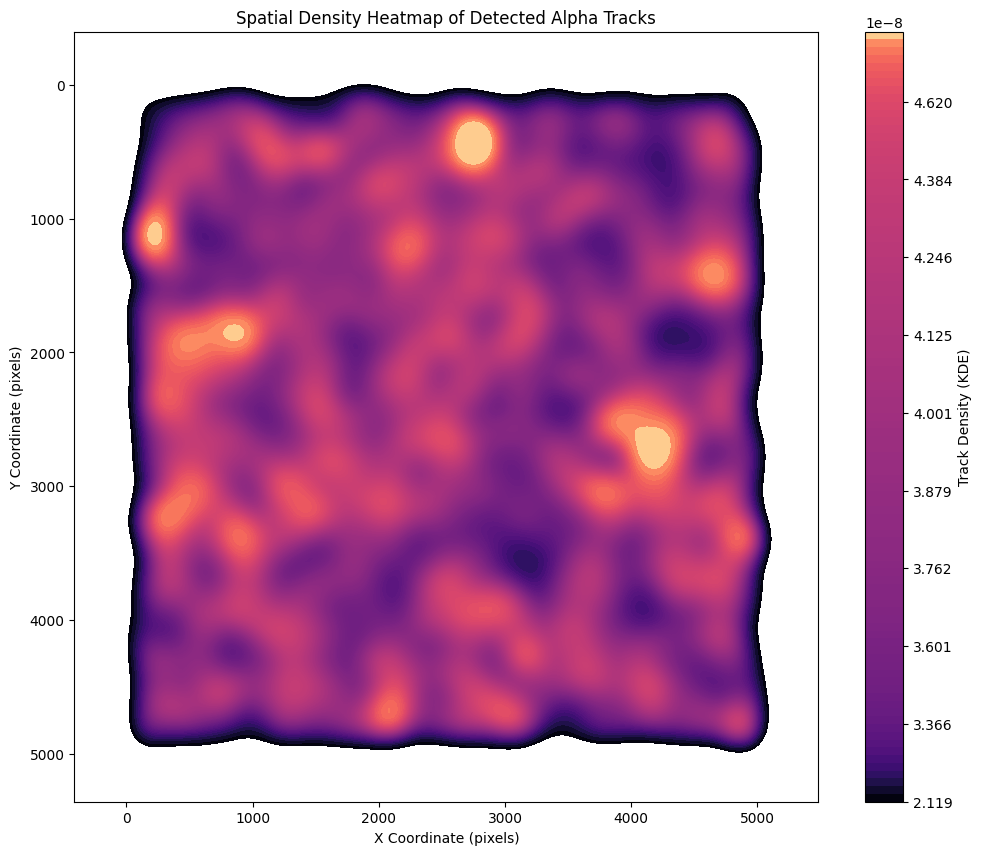

In [ ]:
# Identify coordinate columns using the exact CSV headers
print('Available columns:', df.columns.tolist())

x_col = 'cx'
y_col = 'cy'

if x_col in df.columns and y_col in df.columns:
    plt.figure(figsize=(12, 10))
    
    try:
        # Added cbar=True to display the heatmap legend (colorbar)
        sns.kdeplot(
            x=df[x_col], y=df[y_col], 
            cmap='magma', fill=True, 
            bw_adjust=0.5, levels=100, 
            cbar=True, cbar_kws={'label': 'Track Density (KDE)'}
        )
    except Exception as e:
        print(f'KDE plot failed ({e}), falling back to 2D histogram.')
        # Added cbar=True for the fallback histogram as well
        sns.histplot(
            x=df[x_col], y=df[y_col], 
            bins=100, cmap='magma', pmax=0.9, 
            cbar=True, cbar_kws={'label': 'Track Counts per Bin'}
        )
        
    plt.title('Spatial Density Heatmap of Detected Alpha Tracks')
    plt.xlabel('X Coordinate (pixels)')
    plt.ylabel('Y Coordinate (pixels)')
    # Invert Y axis to match image coordinate systems (origin at top-left)
    plt.gca().invert_yaxis()
    
    os.makedirs('outputs', exist_ok=True)
    plt.savefig('outputs/spatial_density_heatmap.png', dpi=300)
    plt.show()
else:
    print(f'Error: Coordinate columns {x_col} and {y_col} not found in the dataset.')


### Caption
Spatial Density Distribution of Alpha Particle Tracks on CR-39 Detector.
Spatial heatmap illustrating the topological distribution of track centroids across the scanned polymer surface. The local track density was calculated via Gaussian Kernel Density Estimation (KDE) and is represented by the false-color scale (right). A statistically uniform color map indicates an isotropic radiation field and a homogeneous chemical etching response. Conversely, spatial gradients or localized clusters (hot-spots) can be utilized to diagnose systematic experimental anomalies, such as thermal inhomogeneities during the etching bath, reagent concentration gradients, or intrinsic edge-effects of the detector.

### Total count heatmap (binned)

Same spatial layout as above, but each colour bin shows the **raw number of tracks** in that pixel region (2D histogram), not a KDE density estimate.

Bright / pale spots are **dense bins** (many tracks in the same grid cell), not individual tracks. The colour scale is linear from 0 to the maximum bin count.

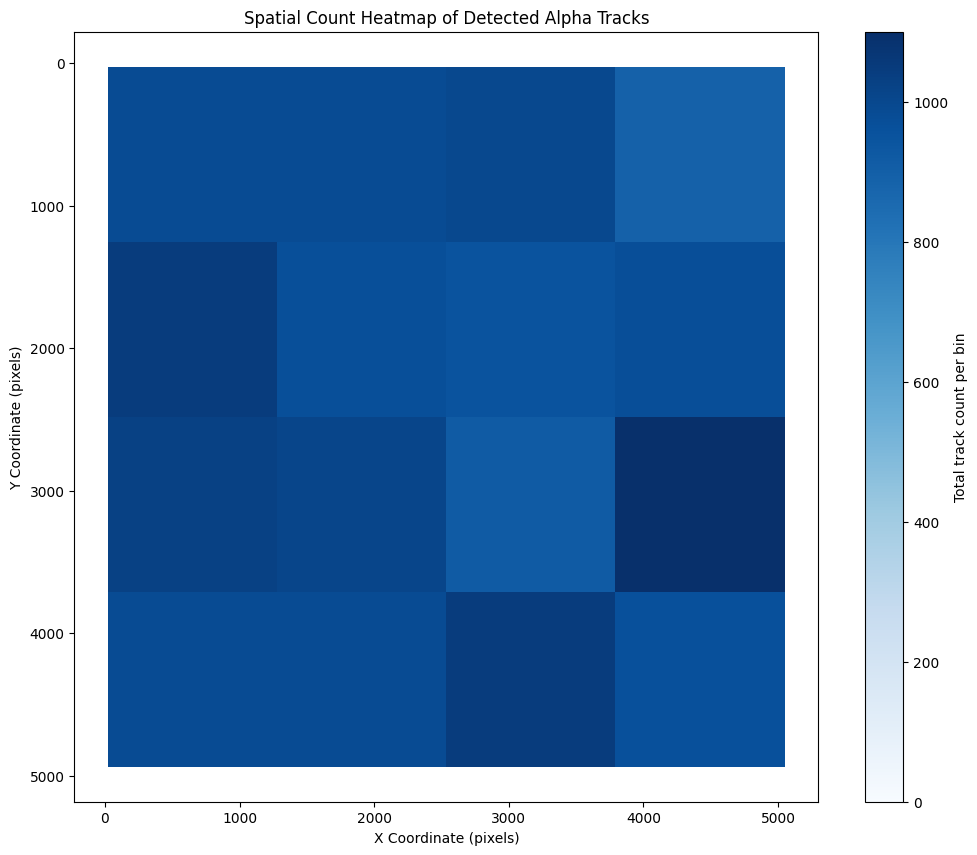

In [ ]:
if x_col in df.columns and y_col in df.columns:
    plt.figure(figsize=(12, 10))

    # Linear count scale (no pmax): avoids clipping dense bins to white/yellow.
    # Magma's top end is still pale — use 'inferno' if you prefer no near-white highs.
    sns.histplot(
        x=df[x_col], y=df[y_col],
        bins=4, cmap='Blues',
        cbar=True, cbar_kws={'label': 'Total track count per bin'},
        stat='count',
    )

    plt.title('Spatial Count Heatmap of Detected Alpha Tracks')
    plt.xlabel('X Coordinate (pixels)')
    plt.ylabel('Y Coordinate (pixels)')
    plt.gca().invert_yaxis()

    os.makedirs('outputs', exist_ok=True)
    plt.savefig('outputs/spatial_count_heatmap.png', dpi=300)
    plt.show()
else:
    print(f'Error: Coordinate columns {x_col} and {y_col} not found in the dataset.')

### Caption
### 2D spatial density mapping of alpha-particle tracks across the CR-39 detector surface.
Spatial heatmap representing the topological distribution of the detected track centroids ($c_x$, $c_y$). The local track density is evaluated using a Gaussian Kernel Density Estimation (KDE), with the magnitude of the spatial gradient quantitatively indicated by the colorbar legend. A statistically uniform spatial distribution implies an isotropic radiation field and a homogeneous response to the chemical etching process. Conversely, the emergence of spatial gradients or localized high-density clusters (hot-spots) serves as a diagnostic tool to identify systematic experimental artifacts, such as thermal fluctuations within the etching bath, reagent concentration gradients, or intrinsic polymer edge-effects.